In [1]:
# =============================================
# 퍼널 분석 — 판매자 지각 분석
# 목적: 판매자 지각일별 최종 정시 도착률,
#       택배사 소요시간, 커버 가능 임계선 탐지
# 베이스: olist_order_item_level.csv
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df_all = pd.read_csv("../../../Funnel_Cohort_NG/data/olist_order_item_level.csv")

# 배송 완료 + 이상치 없는 데이터만
df = df_all[
    df_all['is_delivered'] == True
].copy()

# 날짜 컬럼 변환
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at', 
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# is_seller_late 생성
df['is_seller_late'] = (
    df['order_delivered_carrier_date'] > df['shipping_limit_date']
).astype(float)

# 판매자 지각일 계산
df['seller_delay_days'] = (
    df['order_delivered_carrier_date'] - df['shipping_limit_date']
).dt.days

print('전체 배송 완료:', len(df))
print('판매자 지각률:', round(df['is_seller_late'].mean()*100, 1), '%')
print('판매자 지각 건수:', int(df['is_seller_late'].sum()))
print()
print('컬럼 확인:')
print([c for c in df.columns if 'seller' in c or 'late' in c or 'delay' in c])

전체 배송 완료: 110197
판매자 지각률: 9.3 %
판매자 지각 건수: 10270

컬럼 확인:
['seller_id', 'is_late', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'seller_state_kor', 'seller_region', 'seller_geo_lat', 'seller_geo_lng', 'seller_geo_city', 'seller_geo_state', 'seller_state_geo_mismatch', 'seller_customer_same_state', 'is_seller_late', 'seller_delay_days']


=== 판매자 지각일별 최종 정시 도착률 ===
seller_delay_bucket  total  ontime  ontime_rate
                 1일   1587    1292    81.411468
                 2일    582     434    74.570447
                 3일    486     367    75.514403
               4~5일    883     612    69.309173
               6~7일    644     380    59.006211
              8~14일    615     226    36.747967
               15일+    349      74    21.203438


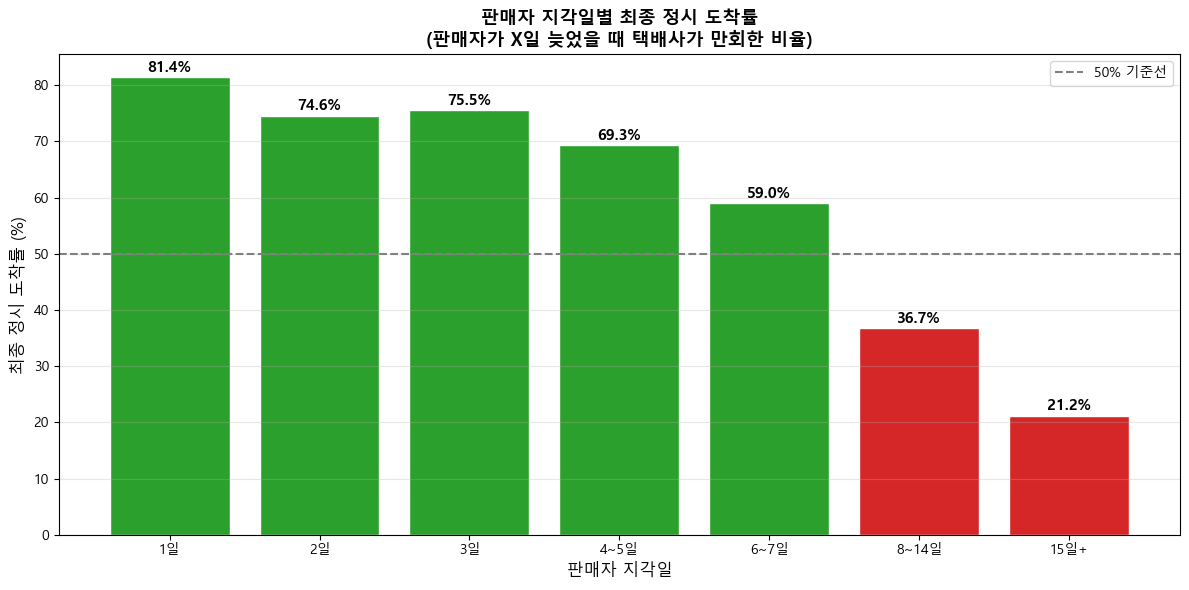

In [2]:
# =============================================
# 분석 1. 판매자 지각일별 최종 정시 도착률
# =============================================

# 판매자 지각일 구간 설정
df_late = df[df['is_seller_late'] == 1].copy()
df_late['seller_delay_bucket'] = pd.cut(
    df_late['seller_delay_days'],
    bins=[0, 1, 2, 3, 5, 7, 14, 999],
    labels=['1일', '2일', '3일', '4~5일', '6~7일', '8~14일', '15일+']
)

# 최종 정시 도착률 (is_late == False)
ontime_rate = df_late.groupby('seller_delay_bucket').agg(
    total=('is_late', 'count'),
    ontime=('is_late', lambda x: (x == False).sum())
).reset_index()
ontime_rate['ontime_rate'] = ontime_rate['ontime'] / ontime_rate['total'] * 100

print('=== 판매자 지각일별 최종 정시 도착률 ===')
print(ontime_rate.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(ontime_rate['seller_delay_bucket'], 
              ontime_rate['ontime_rate'],
              color=['#2ca02c' if x > 50 else '#d62728' for x in ontime_rate['ontime_rate']],
              edgecolor='white')
ax.axhline(50, color='gray', ls='--', lw=1.5, label='50% 기준선')
for bar, rate in zip(bars, ontime_rate['ontime_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('판매자 지각일별 최종 정시 도착률\n(판매자가 X일 늦었을 때 택배사가 만회한 비율)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('판매자 지각일', fontsize=12)
ax.set_ylabel('최종 정시 도착률 (%)', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

=== 지역별 판매자 지각 시 만회율 ===
seller_region  total  ontime  avg_seller_delay  ontime_rate
          북동부    226     120          3.827434    53.097345
           북부      4       3          1.250000    75.000000
          남동부   8420    6406          2.368009    76.080760
           남부   1475    1148          3.947797    77.830508
          중서부    144     118          2.736111    81.944444


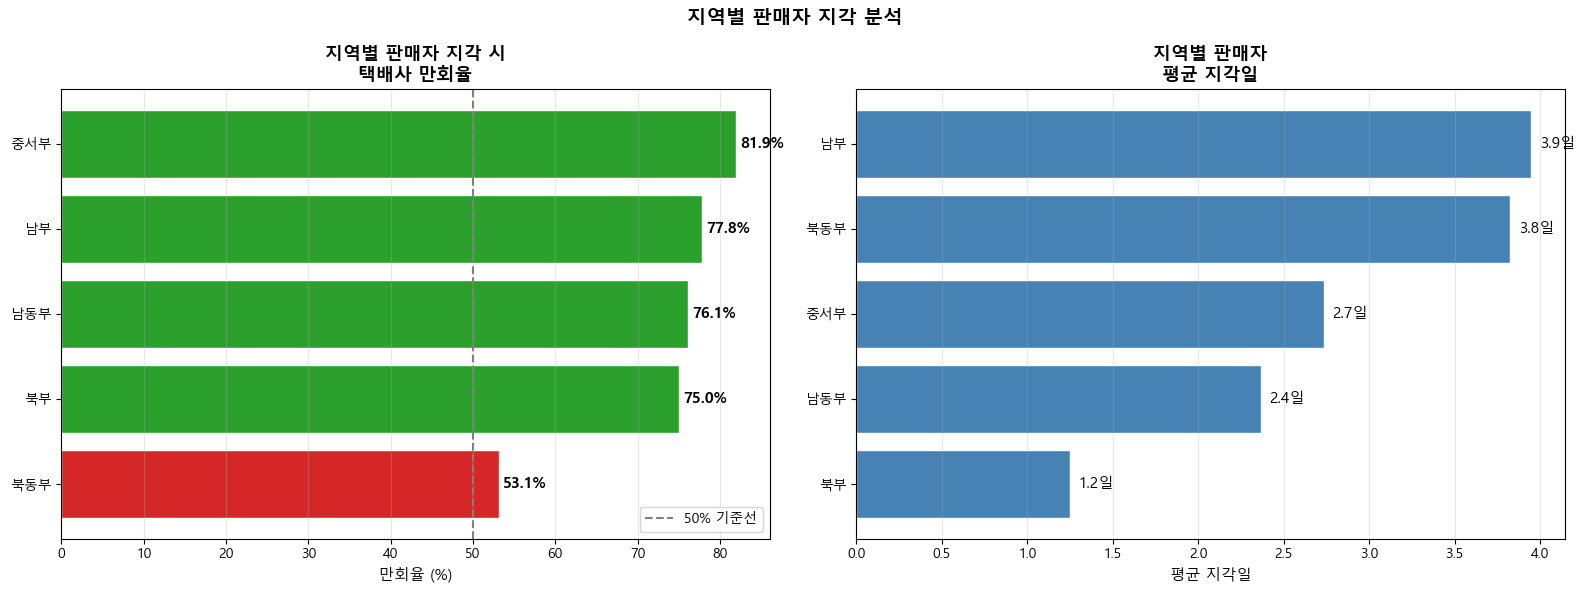

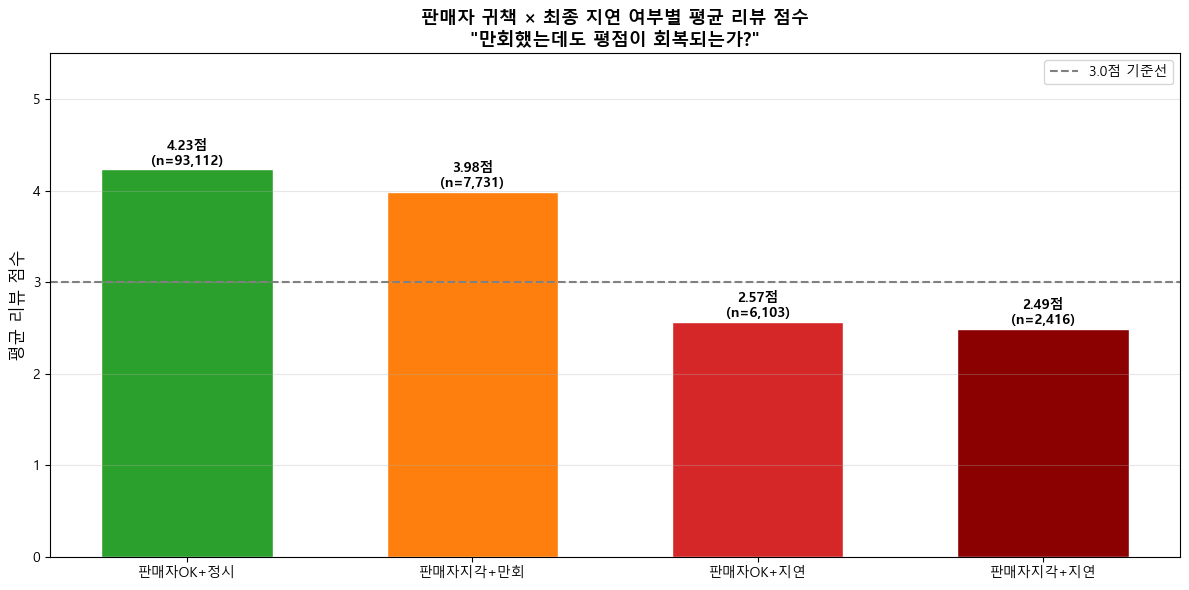

=== 케이스별 평균 리뷰 ===
    case  avg_review  count
판매자OK+정시    4.230445  93112
판매자지각+만회    3.983702   7731
판매자OK+지연    2.570867   6103
판매자지각+지연    2.493377   2416


In [3]:
# =============================================
# 분석 1-1. 지역별 판매자 지각 시 택배사 만회율
# =============================================

region_ontime = df_late.groupby('seller_region').agg(
    total=('is_late', 'count'),
    ontime=('is_late', lambda x: (x == False).sum()),
    avg_seller_delay=('seller_delay_days', 'mean')
).reset_index()
region_ontime['ontime_rate'] = region_ontime['ontime'] / region_ontime['total'] * 100

print('=== 지역별 판매자 지각 시 만회율 ===')
print(region_ontime.sort_values('ontime_rate').to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 지역별 만회율
colors = ['#d62728' if x < 60 else '#ff7f0e' if x < 70 else '#2ca02c' 
          for x in region_ontime.sort_values('ontime_rate')['ontime_rate']]
bars = axes[0].barh(
    region_ontime.sort_values('ontime_rate')['seller_region'],
    region_ontime.sort_values('ontime_rate')['ontime_rate'],
    color=colors, edgecolor='white'
)
axes[0].axvline(50, color='gray', ls='--', lw=1.5, label='50% 기준선')
for bar, rate in zip(bars, region_ontime.sort_values('ontime_rate')['ontime_rate']):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                f'{rate:.1f}%', va='center', fontsize=11, fontweight='bold')
axes[0].set_title('지역별 판매자 지각 시\n택배사 만회율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('만회율 (%)', fontsize=11)
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# 오른쪽: 지역별 판매자 평균 지각일
axes[1].barh(
    region_ontime.sort_values('avg_seller_delay')['seller_region'],
    region_ontime.sort_values('avg_seller_delay')['avg_seller_delay'],
    color='steelblue', edgecolor='white'
)
for i, (_, row) in enumerate(region_ontime.sort_values('avg_seller_delay').iterrows()):
    axes[1].text(row['avg_seller_delay']+0.05, i,
                f'{row["avg_seller_delay"]:.1f}일', va='center', fontsize=11)
axes[1].set_title('지역별 판매자\n평균 지각일', fontsize=13, fontweight='bold')
axes[1].set_xlabel('평균 지각일', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('지역별 판매자 지각 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================
# 분석 1-2. 만회했을 때 평점 vs 완벽 정시 평점
# =============================================

# 4가지 케이스
df['case'] = '기타'
df.loc[(df['is_seller_late']==0) & (df['is_late']==False), 'case'] = '판매자OK+정시'
df.loc[(df['is_seller_late']==0) & (df['is_late']==True), 'case'] = '판매자OK+지연'
df.loc[(df['is_seller_late']==1) & (df['is_late']==False), 'case'] = '판매자지각+만회'
df.loc[(df['is_seller_late']==1) & (df['is_late']==True), 'case'] = '판매자지각+지연'

case_review = df[df['case'] != '기타'].groupby('case')['review_score_mean'].agg(
    ['mean','count']
).reset_index()
case_review.columns = ['case', 'avg_review', 'count']

order = ['판매자OK+정시', '판매자지각+만회', '판매자OK+지연', '판매자지각+지연']
case_review['case'] = pd.Categorical(case_review['case'], categories=order, ordered=True)
case_review = case_review.sort_values('case')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#8b0000']
bars = ax.bar(case_review['case'], case_review['avg_review'],
              color=colors, edgecolor='white', width=0.6)
ax.axhline(3.0, color='gray', ls='--', lw=1.5, label='3.0점 기준선')
for bar, (_, row) in zip(bars, case_review.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{row["avg_review"]:.2f}점\n(n={int(row["count"]):,})',
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('판매자 귀책 × 최종 지연 여부별 평균 리뷰 점수\n"만회했는데도 평점이 회복되는가?"',
             fontsize=13, fontweight='bold')
ax.set_ylabel('평균 리뷰 점수', fontsize=12)
ax.set_ylim(0, 5.5)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('=== 케이스별 평균 리뷰 ===')
print(case_review.to_string(index=False))

=== 판매자 지각일별 택배사 소요시간 ===
판매자 정상 그룹 택배사 중앙값: 7.1일

seller_delay_bucket  median_delivery  mean_delivery  count
                 1일         7.108900       9.769221   1587
                 2일         7.072448       9.310367    582
                 3일         7.314554       9.358083    486
               4~5일         7.110556       9.715940    883
               6~7일         7.777778      10.682255    644
              8~14일         7.637465      10.395885    615
               15일+         7.774537       9.895953    349


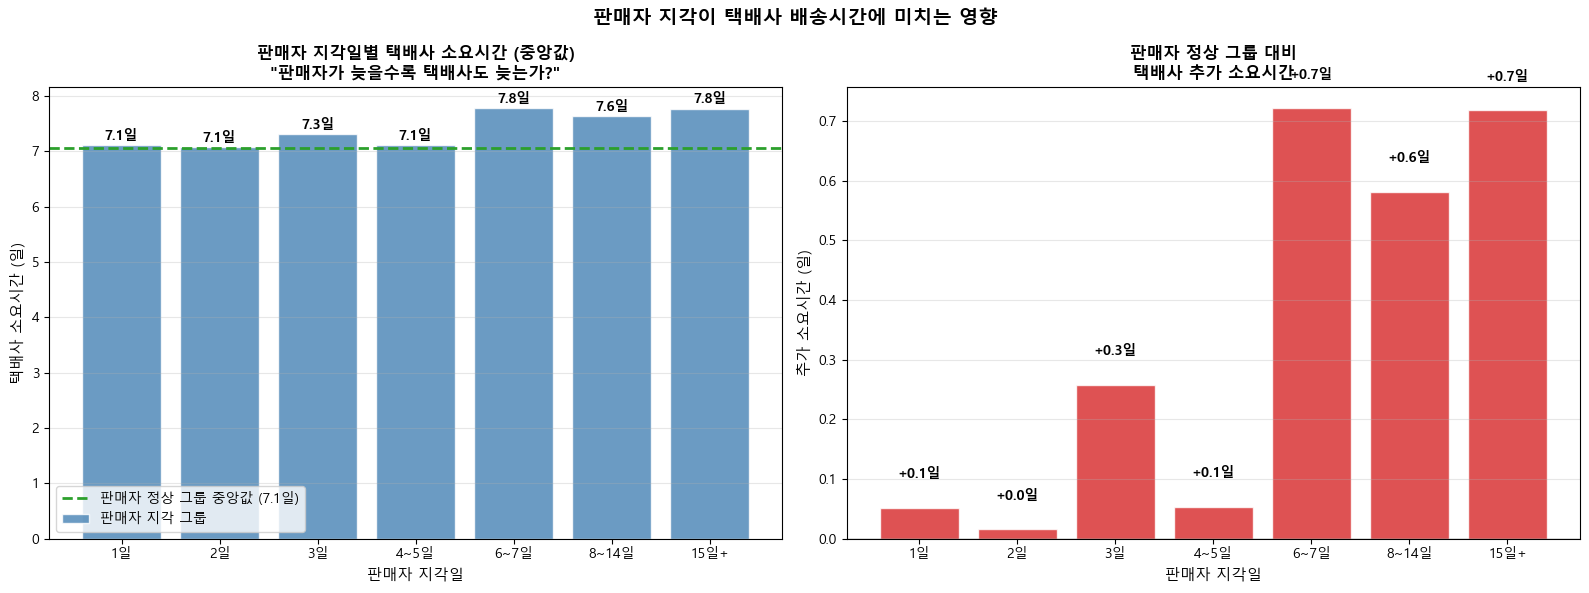

In [4]:
# =============================================
# 분석 2. 판매자 지각일별 택배사 소요시간
# 판매자가 늦을수록 택배사도 늦는가?
# =============================================

# 택배사 소요시간 컬럼 생성
df['t_delivery_d'] = (
    df['order_delivered_customer_date'] - df['order_delivered_carrier_date']
).dt.total_seconds() / 86400

df_late['t_delivery_d'] = (
    df_late['order_delivered_customer_date'] - df_late['order_delivered_carrier_date']
).dt.total_seconds() / 86400

# 정상 판매자 그룹 택배사 소요시간
normal_delivery = df[df['is_seller_late']==0]['t_delivery_d'].median()

# 판매자 지각일별 택배사 소요시간
delivery_by_delay = df_late.groupby('seller_delay_bucket')['t_delivery_d'].agg(
    ['median','mean','count']
).reset_index()
delivery_by_delay.columns = ['seller_delay_bucket','median_delivery','mean_delivery','count']

print('=== 판매자 지각일별 택배사 소요시간 ===')
print(f'판매자 정상 그룹 택배사 중앙값: {normal_delivery:.1f}일')
print()
print(delivery_by_delay.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 택배사 소요시간 비교
axes[0].bar(delivery_by_delay['seller_delay_bucket'],
            delivery_by_delay['median_delivery'],
            color='steelblue', edgecolor='white', alpha=0.8, label='판매자 지각 그룹')
axes[0].axhline(normal_delivery, color='#2ca02c', ls='--', lw=2,
                label=f'판매자 정상 그룹 중앙값 ({normal_delivery:.1f}일)')
for i, row in delivery_by_delay.iterrows():
    axes[0].text(i, row['median_delivery']+0.1,
                f'{row["median_delivery"]:.1f}일',
                ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('판매자 지각일별 택배사 소요시간 (중앙값)\n"판매자가 늦을수록 택배사도 늦는가?"',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('판매자 지각일', fontsize=11)
axes[0].set_ylabel('택배사 소요시간 (일)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 정상 대비 추가 소요시간
delivery_by_delay['extra_days'] = delivery_by_delay['median_delivery'] - normal_delivery
colors = ['#d62728' if x > 0 else '#2ca02c' for x in delivery_by_delay['extra_days']]
axes[1].bar(delivery_by_delay['seller_delay_bucket'],
            delivery_by_delay['extra_days'],
            color=colors, edgecolor='white', alpha=0.8)
axes[1].axhline(0, color='gray', ls='-', lw=1)
for i, row in delivery_by_delay.iterrows():
    axes[1].text(i, row['extra_days']+0.05 if row['extra_days'] >= 0 else row['extra_days']-0.3,
                f'+{row["extra_days"]:.1f}일' if row['extra_days'] >= 0 else f'{row["extra_days"]:.1f}일',
                ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('판매자 정상 그룹 대비\n택배사 추가 소요시간',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('판매자 지각일', fontsize=11)
axes[1].set_ylabel('추가 소요시간 (일)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('판매자 지각이 택배사 배송시간에 미치는 영향', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== 배송 타이밍별 평균 리뷰 점수 ===
 timing  avg_review  count
 7일+ 빠름    4.225917  86858
4~7일 빠름    4.132201  10658
2~3일 빠름    4.090021   3327
  1일 빠름    3.987117   1436
     정시    3.679185    932
1~3일 지연    2.869377   1156
4~7일 지연    2.089810   1943
 7일+ 지연    1.697903   3052


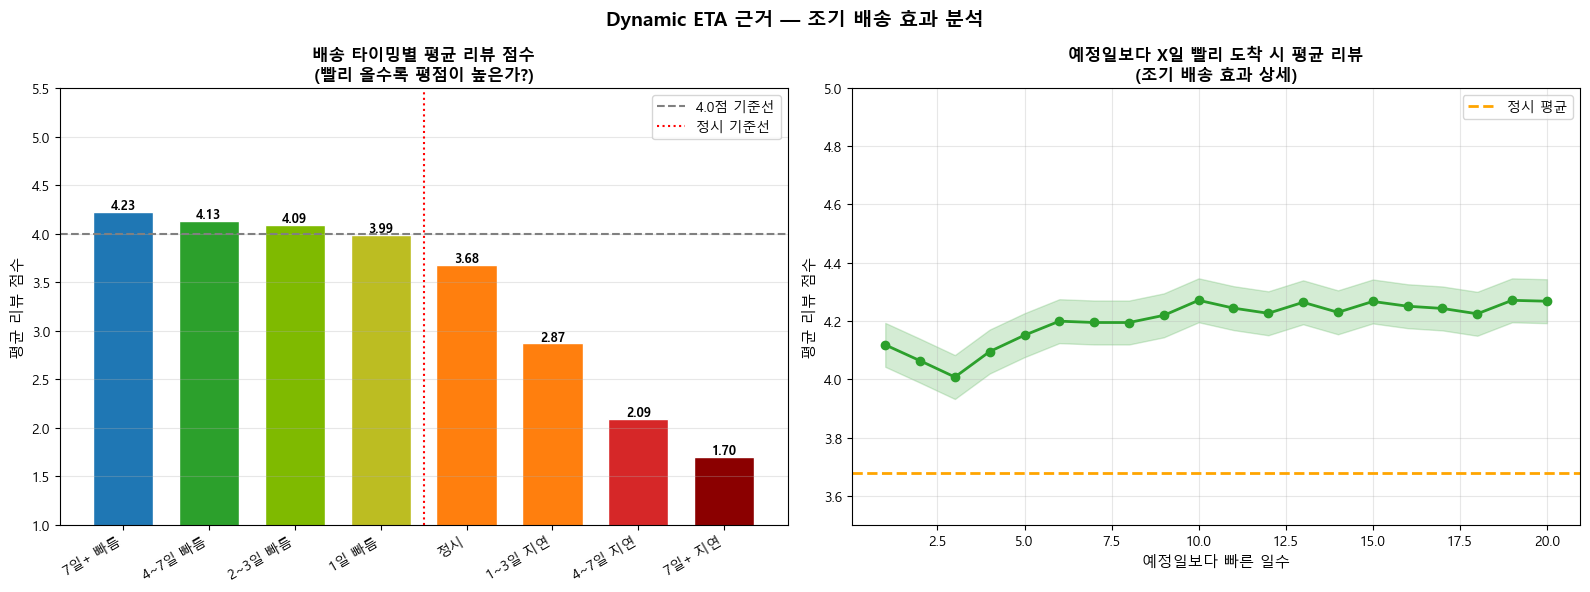

In [5]:
# =============================================
# 분석 3. 조기 배송 효과 — Dynamic ETA 근거
# 예정일보다 일찍 도착할수록 평점이 높은가?
# =============================================

# delay_days 음수 = 조기 배송
df_early = df[df['is_late'].notna()].copy()
df_early['delay_days'] = (
    df_early['order_delivered_customer_date'] - 
    df_early['order_estimated_delivery_date']
).dt.days

# 조기/정시/지연 구간 설정
df_early['delivery_timing'] = pd.cut(
    df_early['delay_days'],
    bins=[-999, -7, -3, -1, 0, 1, 3, 7, 999],
    labels=['7일+ 빠름', '4~7일 빠름', '2~3일 빠름', '1일 빠름', 
            '정시', '1~3일 지연', '4~7일 지연', '7일+ 지연']
)

timing_review = df_early.groupby('delivery_timing')['review_score_mean'].agg(
    ['mean', 'count']
).reset_index()
timing_review.columns = ['timing', 'avg_review', 'count']

print('=== 배송 타이밍별 평균 리뷰 점수 ===')
print(timing_review.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 타이밍별 평균 리뷰
colors = ['#1f77b4','#2ca02c','#7fba00','#bcbd22',
          '#ff7f0e','#ff7f0e','#d62728','#8b0000']
bars = axes[0].bar(range(len(timing_review)), timing_review['avg_review'],
                   color=colors, edgecolor='white', width=0.7)
axes[0].axhline(4.0, color='gray', ls='--', lw=1.5, label='4.0점 기준선')
axes[0].axvline(3.5, color='red', ls=':', lw=1.5, label='정시 기준선')
for bar, (_, row) in zip(bars, timing_review.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                f'{row["avg_review"]:.2f}',
                ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(range(len(timing_review)))
axes[0].set_xticklabels(timing_review['timing'], rotation=30, ha='right', fontsize=10)
axes[0].set_title('배송 타이밍별 평균 리뷰 점수\n(빨리 올수록 평점이 높은가?)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[0].set_ylim(1, 5.5)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 조기 배송 구간별 상세 (음수 구간만)
df_before = df_early[df_early['delay_days'] < 0].copy()
df_before['early_day'] = df_before['delay_days'].abs()
daily_early = df_before.groupby('early_day')['review_score_mean'].agg(
    ['mean','count']
)
daily_early = daily_early[daily_early['count'] >= 30].loc[:20]

axes[1].plot(daily_early.index, daily_early['mean'], 
             'o-', color='#2ca02c', lw=2, ms=6)
axes[1].axhline(timing_review[timing_review['timing']=='정시']['avg_review'].values[0],
                color='orange', ls='--', lw=2, label='정시 평균')
axes[1].fill_between(daily_early.index, 
                     daily_early['mean'] - daily_early['mean'].std(),
                     daily_early['mean'] + daily_early['mean'].std(),
                     alpha=0.2, color='#2ca02c')
axes[1].set_title('예정일보다 X일 빨리 도착 시 평균 리뷰\n(조기 배송 효과 상세)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('예정일보다 빠른 일수', fontsize=11)
axes[1].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(3.5, 5)

plt.suptitle('Dynamic ETA 근거 — 조기 배송 효과 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()